In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

from core.IntensityModes import laguerre_gauss as Lg
from core.IntensityModes import hermite_gauss as Hg, hermite_gauss_1d as Hg_1d
from core.Polarization_elements import polarizers,scalar_to_vector, filter_polarizer,q_plate as qp
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product as dp
from core.Optical_elements import angular_spectrum as angSpec, tilt, mirror,beam_splitter as bs, lens

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

from tqdm import trange

(<Figure size 640x480 with 1 Axes>, <Axes: >)

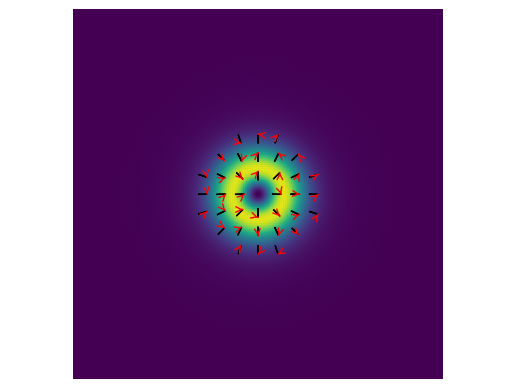

In [9]:
n = 2000
x = np.linspace(-1e-2/4,1e-2/4,n)
y = np.linspace(-1e-2/4,1e-2/4,n)
x,y = np.meshgrid(x,y)

lg = Lg(x, y,w0=1e-4)
lg = scalar_to_vector(lg,(1,0j))
#I(lg)
#lg = polarizers(lg,np.pi/4,'quarter')
lg = qp(x,y,lg)

lg = angSpec(lg,x,y,.20)
#lg = filter_polarizer(lg,np.pi/4,'linear')
I(lg)

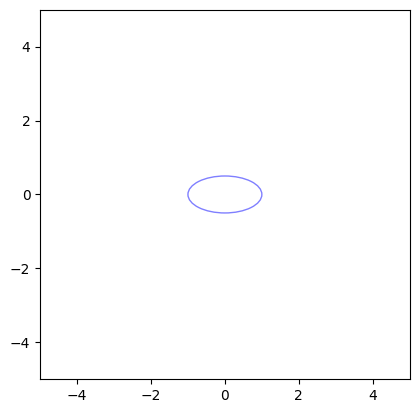

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()

# lista de elipses: (x, y, largura, altura, ângulo)
import numpy as np
for i in range(1):
    e = Ellipse(
        xy=(0, 0),
        width=2,
        height=1,
        angle=0,
        edgecolor='blue',
        facecolor='none',
        alpha=0.5
    )
    ax.add_patch(e)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')

plt.show()

The slowest run took 6.52 times longer than the fastest. This could mean that an intermediate result is being cached.
1.74 s ± 919 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


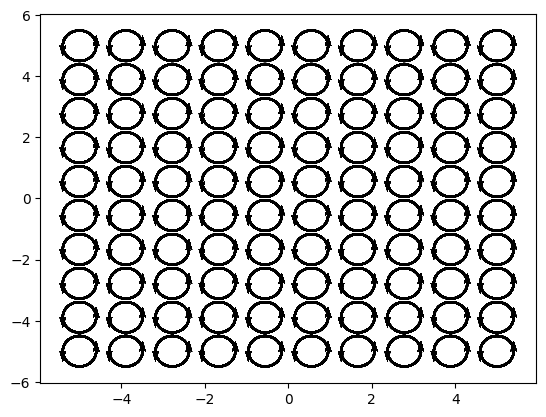

In [ ]:
m = 10
X, Y = np.meshgrid(np.linspace(-5,5,m), np.linspace(-5,5,m))
n = 51
for i in range(len(X)):
    for j in range(len(X)):
        t = np.linspace(0, 2*np.pi, n)

        a, b = 0.4, 0.5
        x = X[i,j] + a*np.cos(t)
        y = Y[i,j] + b*np.sin(t)

        dx = -a*np.sin(t)
        dy =  b*np.cos(t)

        plt.plot(x, y, color='black')
        plt.quiver(x[::n//2], y[::n//2], dx[::n//2], dy[::n//2],
                   angles='xy', scale_units='xy', scale=1.5)

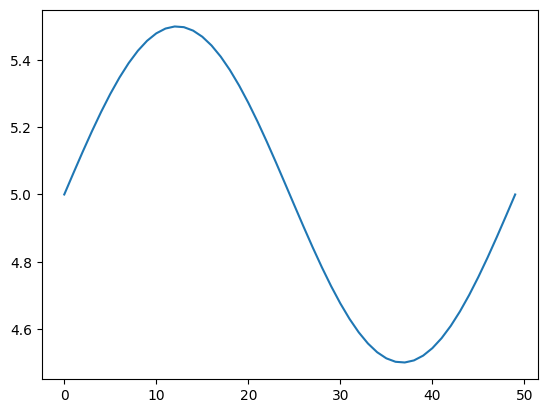

In [28]:
plt.plot(y)

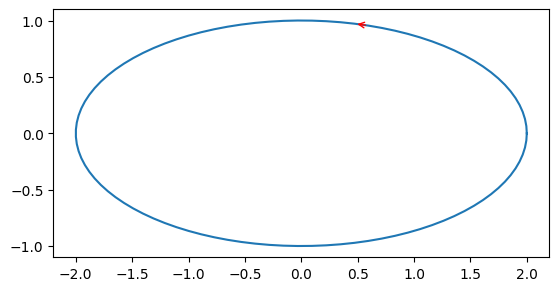

In [3]:

t = np.linspace(0, 2*np.pi, 100)

a, b = 2, 1  # semi-eixos
x = a * np.cos(t)
y = b * np.sin(t)

# derivada (direção do movimento)
dx = -a * np.sin(t)
dy =  b * np.cos(t)

plt.figure()

# elipse
plt.plot(x, y)

i = 20  # ponto da elipse
plt.annotate(
    '',
    xy=(x[i+1], y[i+1]),
    xytext=(x[i], y[i]),
    arrowprops=dict(arrowstyle='->', color='red')
)
plt.gca().set_aspect('equal')
plt.show()

In [110]:
n = 2000
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

w0 = 1.8e-3
x1 = x[0, :]
y1 = y[:, 0]

dx = x1[1] - x1[0]
dy = y1[1] - y1[0]

Hx = []
Hy = []
max_mode = 40
for n in range(max_mode):
    hx = Hg_1d(x1,n,w0)
    Hx.append(hx)
for m in range(max_mode):
    hy = Hg_1d(y1,m,w0)
    Hy.append(hy)


Hx = np.array(Hx) * np.sqrt(dx)
Hy = np.array(Hy) * np.sqrt(dy)

mat = Hx @ Hx.T *(np.abs(Hx @ Hx.T)  > 1e-15)
print(np.sum(Hx @ Hx.T))
print(np.sum(mat))
print(mat)
print(Hx @ Hx.T)
#print(Hy @ Hy.T)

31.075626880742675
31.075626880742675
[[ 1.00000000e+00 -0.00000000e+00  0.00000000e+00 ... -0.00000000e+00
  -1.15050258e-15 -0.00000000e+00]
 [-0.00000000e+00  1.00000000e+00  0.00000000e+00 ... -2.46926606e-14
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 ...  0.00000000e+00
  -1.05030496e-13 -0.00000000e+00]
 ...
 [-0.00000000e+00 -2.46926606e-14  0.00000000e+00 ...  7.04318540e-01
   0.00000000e+00 -2.55240181e-01]
 [-1.15050258e-15  0.00000000e+00 -1.05030496e-13 ...  0.00000000e+00
   7.04642874e-01  0.00000000e+00]
 [-0.00000000e+00  0.00000000e+00 -0.00000000e+00 ... -2.55240181e-01
   0.00000000e+00  7.04305911e-01]]
[[ 1.00000000e+00 -1.68094711e-17  1.46854048e-16 ... -9.90250994e-18
  -1.15050258e-15 -5.89788379e-19]
 [-1.68094711e-17  1.00000000e+00  2.02540706e-16 ... -2.46926606e-14
   1.39034341e-17  4.20332956e-16]
 [ 1.46854048e-16  2.02540706e-16  1.00000000e+00 ...  2.07739476e-17
  -1.05030496e-13 -8.20003031e-17]
 ...
 [-9.9

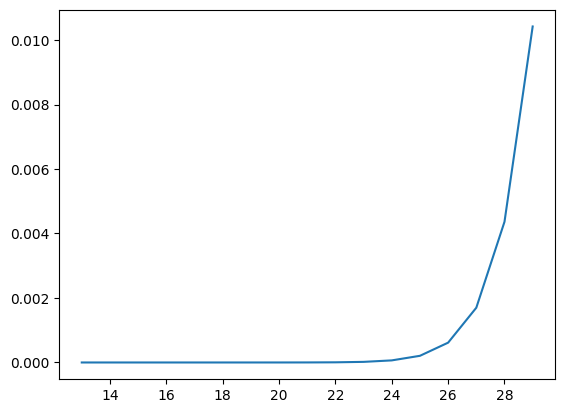

In [84]:
n = 2000
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

w0 = 1.8e-3
x1 = x[0, :]
y1 = y[:, 0]

dx = x1[1] - x1[0]
dy = y1[1] - y1[0]
errox = []
erroy = []
modes = []
for i in range(13,30):
    Hx = []
    Hy = []
    max_mode = i
    #print(max_mode)
    modes.append(max_mode)
    for n in range(max_mode):
        hx = Hg_1d(x1,n,w0)
        Hx.append(hx)
    for m in range(max_mode):
        hy = Hg_1d(y1,m,w0)
        Hy.append(hy)


    Hx = np.array(Hx) * np.sqrt(dx)
    Hy = np.array(Hy) * np.sqrt(dy)


    errox.append(np.linalg.norm(Hx @ Hx.T - np.eye(max_mode)))
    erroy.append(np.linalg.norm(Hy @ Hy.T - np.eye(max_mode)))
errox = np.array(errox)
erroy = np.array(erroy)
modes = np.array(modes)
plt.plot(modes,errox)

In [83]:
linregress(np.log(modes), np.log(errox))

LinregressResult(slope=np.float64(29.083555098751045), intercept=np.float64(-102.20970716713231), rvalue=np.float64(0.999880238827266), pvalue=np.float64(1.4177760561028879e-28), stderr=np.float64(0.11622883700862985), intercept_stderr=np.float64(0.35166613289380083))

Shape da imagem: (640, 480)


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\iuryp\AppData\Local\Temp\ipykernel_14704\2084879729.py:6: SyntaxWarning: invalid escape sequence '\m'
  img = Image.open("photos\momo_linda.jpeg").convert("L")


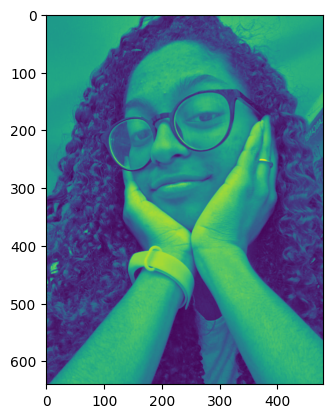

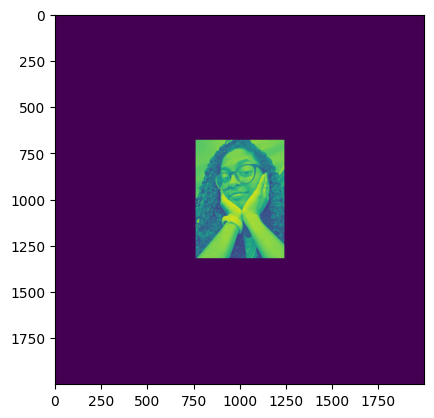

entrei
passei
Erro ortonormalidade Hx: 6.059894819911308e-11
Erro ortonormalidade Hy: 6.059894819911308e-11
Erro relativo de reconstrução: 0.3065117922391873


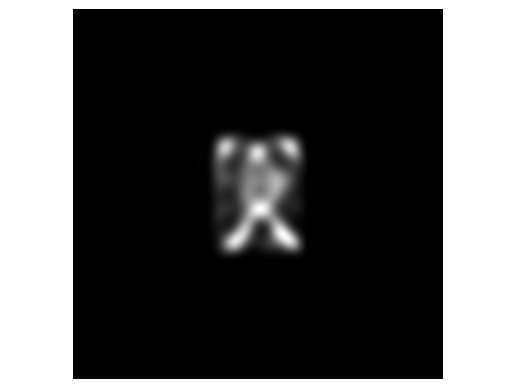

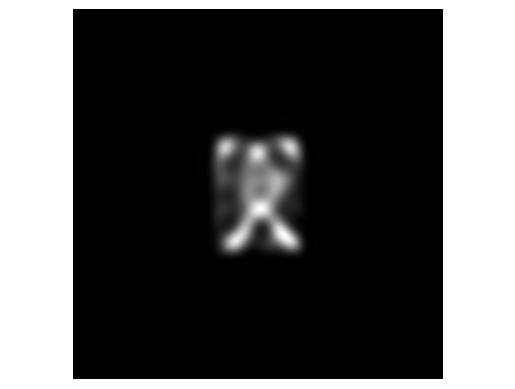

lente1


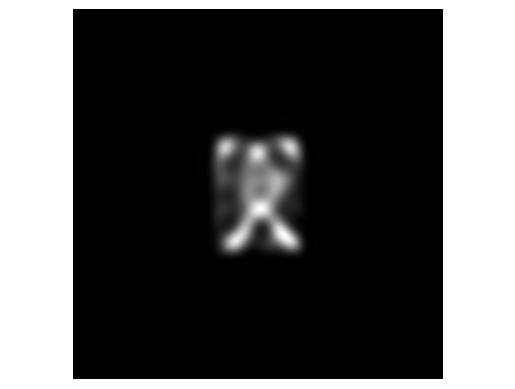

f


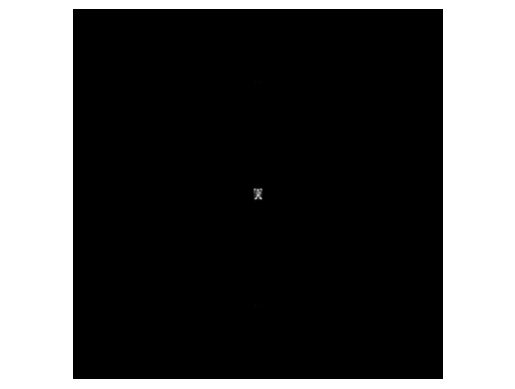

2f


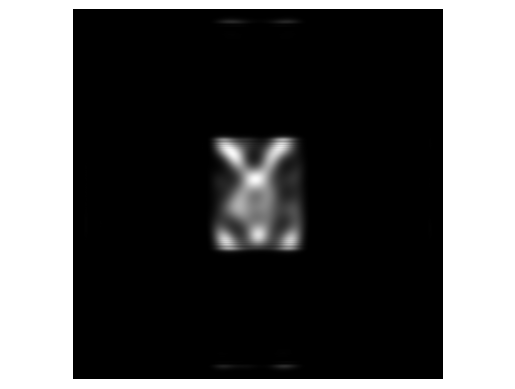

lente2


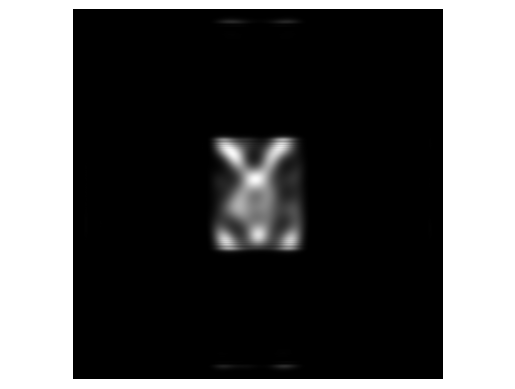

f


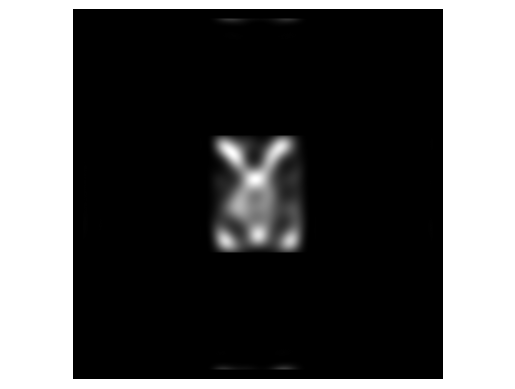

In [19]:
n = 2000
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

img = Image.open("photos\momo_linda.jpeg").convert("L")
img = img.resize((img.size[0]//2, img.size[1]//2))

img_array = (np.array(img)/np.max(img))#[0:960,0:960]
print("Shape da imagem:", img_array.shape)
plt.imshow(img_array)
plt.show()
f = np.zeros_like(Hg(x,y))

H, W = f.shape
h, w = img_array.shape

i0 = (H - h) // 2
j0 = (W - w) // 2

f[i0:i0+h, j0:j0+w] = np.sqrt(img_array)
plt.imshow(np.abs(f))
plt.show()

w0 = 1.8e-3
x1 = x[0, :]
y1 = y[:, 0]

dx = x1[1] - x1[0]
dy = y1[1] - y1[0]

max_mode = 15

Hx = []
Hy = []

print('entrei')
for n in range(max_mode):
    hx = Hg_1d(x1,n,w0)
    Hx.append(hx)
print('passei')
for m in range(max_mode):
    hy = Hg_1d(y1,m,w0)
    Hy.append(hy)


Hx = np.array(Hx) * np.sqrt(dx)
Hy = np.array(Hy) * np.sqrt(dy)

#Hx = np.linalg.qr(Hx.T)[0].T
#Hy = np.linalg.qr(Hy.T)[0].T

print("Erro ortonormalidade Hx:", np.linalg.norm(Hx @ Hx.T - np.eye(max_mode)))
print("Erro ortonormalidade Hy:", np.linalg.norm(Hy @ Hy.T - np.eye(max_mode)))


proj_x = np.tensordot(f, np.conj(Hx), axes=([1], [1]))      # (Ny, n)

coeffs_array = np.tensordot(np.conj(Hy), proj_x, axes=([1], [0]))  # (m, n)


f_rec = Hy.T @ coeffs_array @ Hx


erro = np.linalg.norm(f - f_rec) / np.linalg.norm(f)
print("Erro relativo de reconstrução:", erro)

modet_prop = f_rec
I(modet_prop,'grey')
plt.show()
focal = .1
modet_prop = angSpec(modet_prop, x, y, z=focal)
I(modet_prop,'grey')
plt.show()

modet_prop = lens(modet_prop, x, y, f=focal)
print('lente1')
I(modet_prop,'grey')
plt.show()

modet_test = angSpec(modet_prop, x, y, z=focal-.01)
print('f')
I(modet_test,'grey')
plt.show()

modet_prop = angSpec(modet_prop, x, y, z=2*focal)
print('2f')
I(modet_prop,'grey')
plt.show()

modet_prop = lens(modet_prop, x, y, f=focal)
print('lente2')
I(modet_prop,'grey')
plt.show()

modet_prop = angSpec(modet_prop, x, y, z=focal)
print('f')
I(modet_prop,'grey')
plt.show()


0.5000000000000744 0.5000000000000744
234184.72006333384
2.4384696654106264e-166
0.5000000000000744


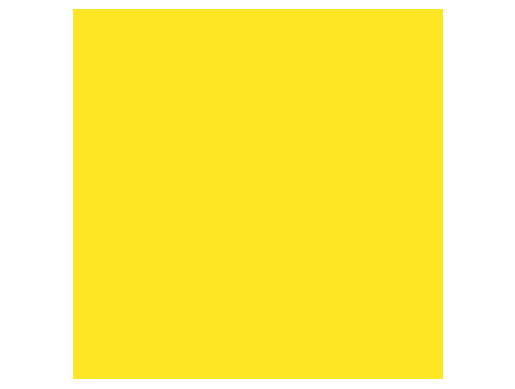

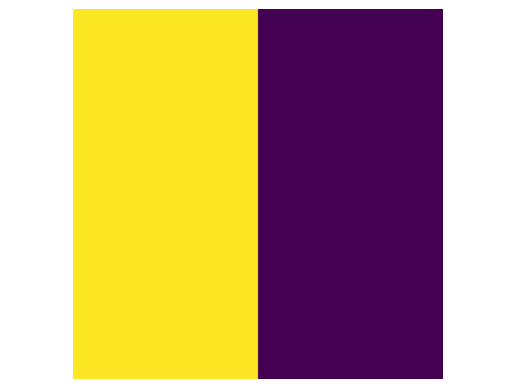

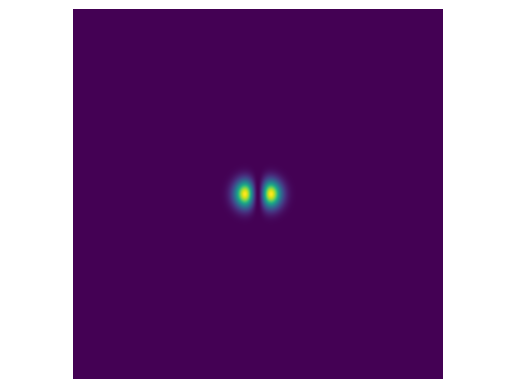

In [4]:
n = 2000
dx = 1e-3
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

hg = Hg(x, y, 1)
arm1,arm2 = bs(hg)
print(pwr(x,y,arm1), pwr(x,y,arm2))
I(phi(arm2))
I(phi(arm1))
I(arm2)

print(np.max(np.abs(arm2)**2))
print(np.min(np.abs(arm2)**2))
print(pwr(x,y,arm2))

1.000000000000148


(<Figure size 640x480 with 1 Axes>, <Axes: >)

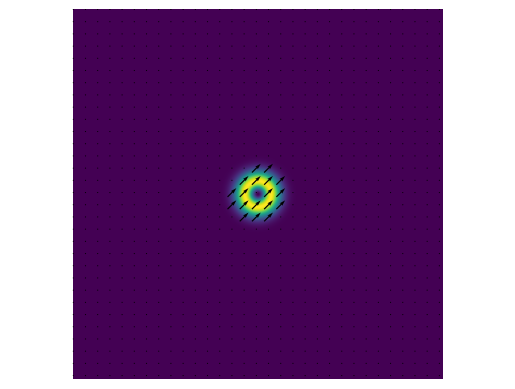

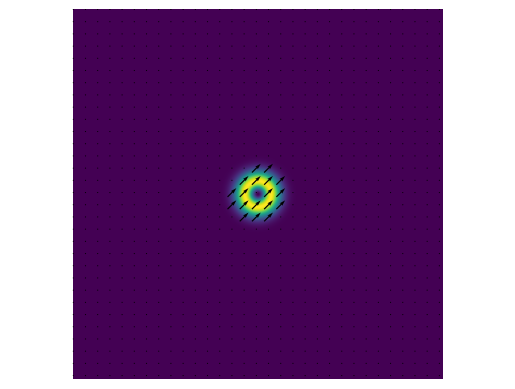

In [30]:
n = 2000
dx = 1e-3
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

lg = Lg(x, y, 1)
lg = scalar_to_vector(lg,(1,1))

I(mirror(lg,theta=np.pi/2,rs=1j))
print(pwr(x,y,mirror(lg,theta=np.pi/2,rs=1j)))
I(((lg)))

(<Figure size 640x480 with 1 Axes>, <Axes: >)

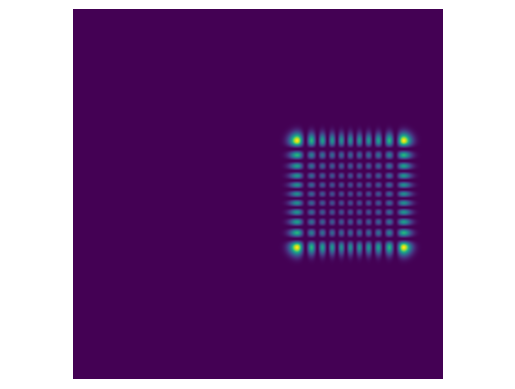

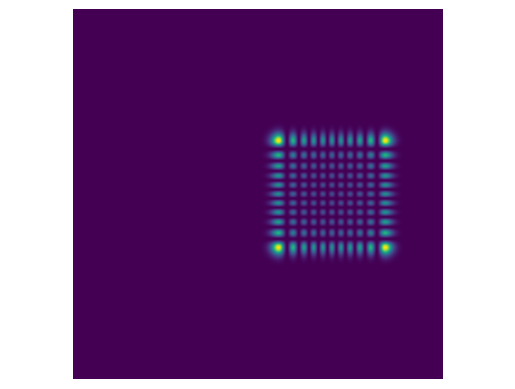

In [3]:
n = 2000
x = np.linspace(-1.5e-2,.5e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)
z1 = 0.2
hg = Hg(x, y, 10, 10)
I(hg)
hg = np.roll(hg,-100)
I(hg)

1.246081328418216


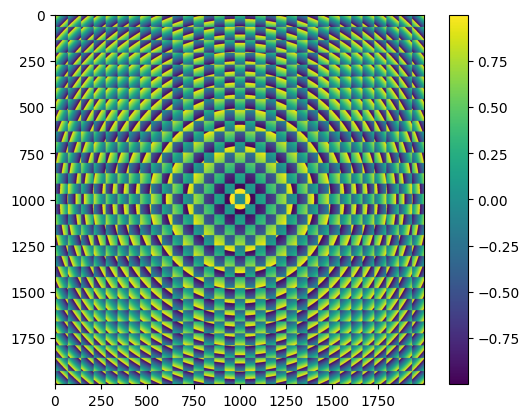

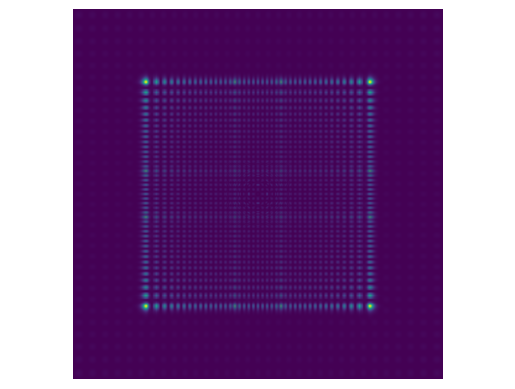

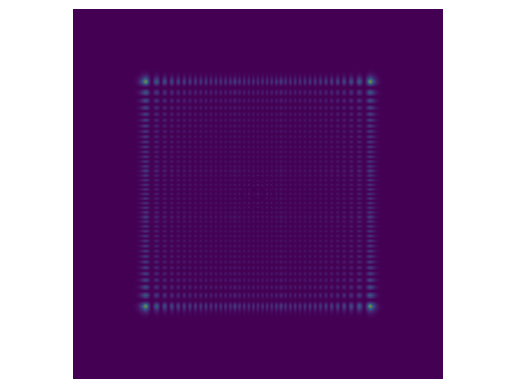

In [95]:
n = 2000
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)
z1 = 0.2
hg = Hg(x, y, 40, 40)
hg1 = Hg(x, y, 40, 40,z=10)
hg2 = angSpec(angSpec(lens(hg, x, y, f=z1), x, y, z=z1),x, y, z=z1)
print(pwr(x,y,hg1+hg2))

plt.imshow(phi(hg1)/np.pi)
plt.colorbar()
I(hg1 + hg2)
I(hg-hg2)
plt.show()

In [87]:
phi(hg1)[1000,1000]/np.pi

np.float64(0.7312448657031599)

1.0000000000001479
0.5000000000000742
0.5000000000000742
0.9999999999999115


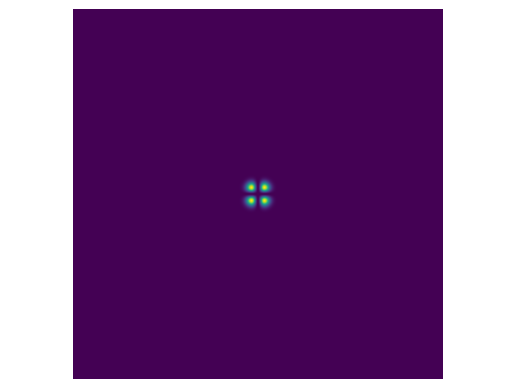

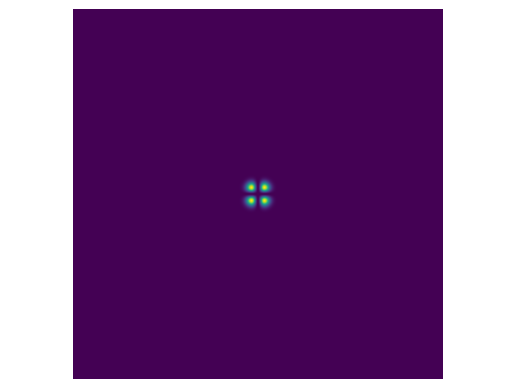

In [2]:
# creating the space
x = np.linspace(-2e-2,2e-2,2000)
y = np.linspace(-2e-2,2e-2,2000)
x,y = np.meshgrid(x,y)

hg = Hg(x, y, 1, 1)
print(pwr(x,y,hg))
hg1,hg2 = bs(hg)
I(hg1+hg2)
I(hg2)
hg_n = hg1 + tilt(hg2, x, y, safe=False, thetax=np.pi/4)
print(pwr(x,y,hg1))
print(pwr(x,y,hg2))
print(pwr(x,y,hg_n))

0.5000000000000739
0.5000000000000739
1.0000000000001479
0.0
1.0000000000001479 1.0000000000001479 1.0000000000001479


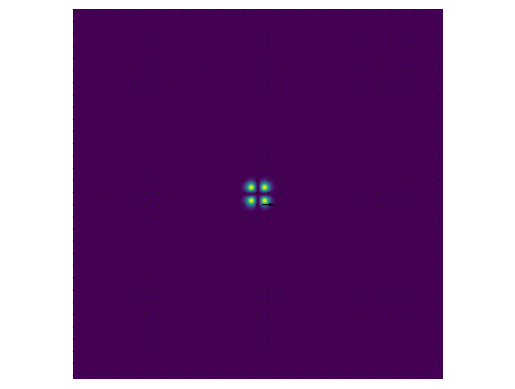

In [12]:
# creating the space
x = np.linspace(-2e-2,2e-2,2000)
y = np.linspace(-2e-2,2e-2,2000)
x,y = np.meshgrid(x,y)
theta = 0.0005
hg = Hg(x, y, 1, 1)
hg = scalar_to_vector(hg,(1,1))
field_back = mirror(hg, x, y, theta=theta,phi=0,rs=-1,rp=1j)
hg_n = hg + field_back
I(hg_n)
print(pwr(x,y,filter_polarizer(field_back,-45,'linear')))
print(pwr(x,y,filter_polarizer(field_back,45,'linear')))
print(pwr(x,y,filter_polarizer(field_back,0,'Rcirc')))
print(pwr(x,y,filter_polarizer(field_back,0,'Lcirc')))
print(pwr(x,y,hg),
pwr(x,y,field_back),
pwr(x,y,hg_n))


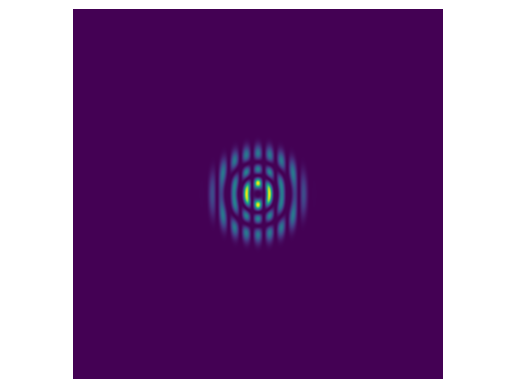

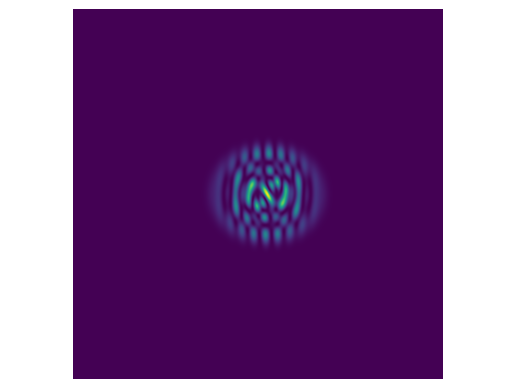

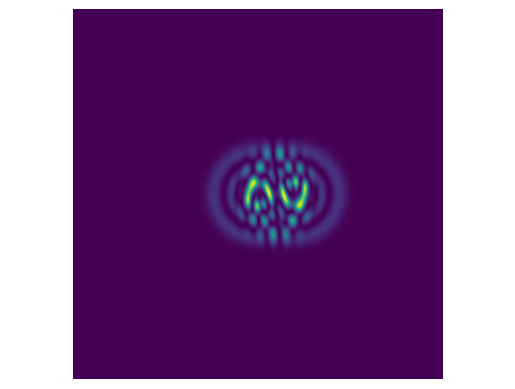

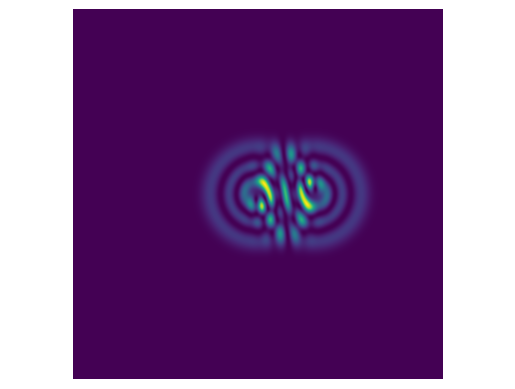

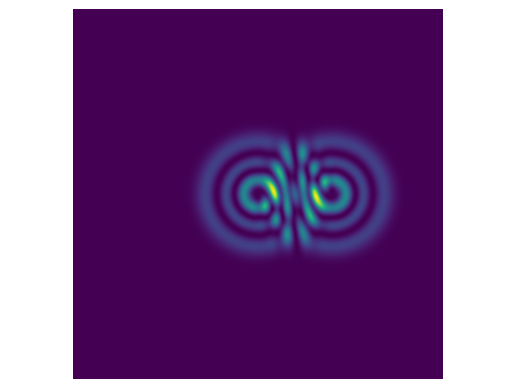

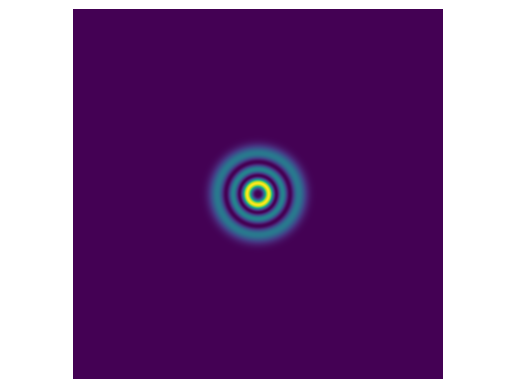

In [5]:
# creating the space
x = np.linspace(-1e-2,1e-2,1000)
y = np.linspace(-1e-2,1e-2,1000)
x,y = np.meshgrid(x,y)

# creating the intensity profile (2-dimensional)
lg = Lg(x,y,2,2)
# ploting (comparing the analitical and the simulated propagation)
I(lg_n := lg+tilt(lg,x,y,.001))
I(angSpec(lg_n,x,y,1))
I(angSpec(lg_n,x,y,2))
I(angSpec(lg_n,x,y,3))
I(angSpec(lg_n,x,y,4))
I(lg)
plt.show()

0.9999999999999487
0.9999999999999487
1.1368683772161603e-13


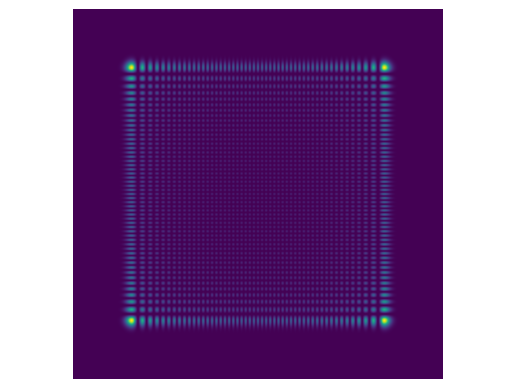

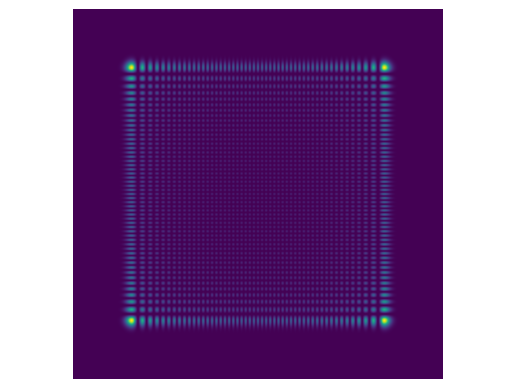

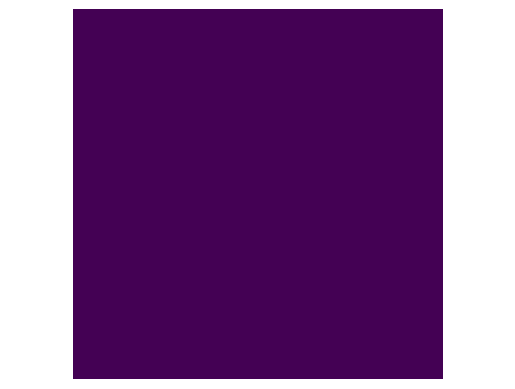

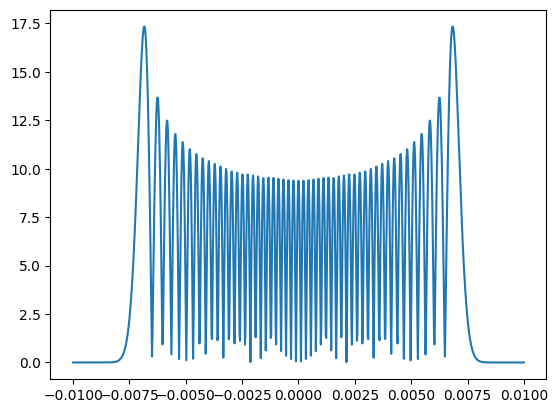

In [4]:
# creating the space
x = np.linspace(-1e-2,1e-2,1000)
y = np.linspace(-1e-2,1e-2,1000)
x,y = np.meshgrid(x,y)

# creating the intensity profile (2-dimensional)
mn = 50
hg = Hg(x,y,mn,mn)
hg1d = Hg_1d(x[0, :],mn)
I(hg)
print(pwr(x,y,hg))
I(hg_n := np.outer(hg1d,hg1d))
print(pwr(x,y,hg_n))
I(hg-hg_n)
print(np.max(np.abs(hg_n - hg)))
plt.show()
plt.plot(x[0, :], np.abs(hg1d))
plt.show()